In [31]:
from __future__ import annotations

from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import boto3
from botocore import UNSIGNED
from botocore.client import Config

from datetime import datetime, timezone
import xradar as xd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.interpolate import griddata
from pyproj import CRS, Transformer

In [50]:
LEVEL2_BUCKET = "unidata-nexrad-level2"

def _normalize_level2_site(site: str) -> str:
    """
    Normalisiert einen Radarcode für Level II.
    Beispiel:
      TLX  -> KTLX
      KTLX -> KTLX
    """
    site = site.upper().strip()
    if len(site) == 3:
        return f"K{site}"
    return site


def _parse_level2_key_timestamp(key: str) -> Optional[datetime]:
    """
    Erwartetes Format:
      YYYY/MM/DD/KTLX/KTLX20240502_060123_V06
    """
    name = Path(key).name

    # Beispielname: KTLX20240502_060123_V06
    # Station = 4 Zeichen, Datum = 8, Uhrzeit = 6
    if len(name) < 4 + 8 + 1 + 6:
        return None

    try:
        datestr = name[4:12]      # YYYYMMDD
        timestr = name[13:19]     # HHMMSS
        return datetime.strptime(datestr + timestr, "%Y%m%d%H%M%S").replace(
            tzinfo=timezone.utc
        )
    except Exception:
        return None


def _list_level2_keys_for_day(
    s3,
    site: str,
    day: datetime,
    bucket: str = LEVEL2_BUCKET,
) -> List[str]:
    """
    Listet alle Keys für einen Tag und eine Radarstation.
    """
    prefix = f"{day:%Y}/{day:%m}/{day:%d}/{site}/"
    paginator = s3.get_paginator("list_objects_v2")

    keys: List[str] = []
    for page in paginator.paginate(Bucket=bucket, Prefix=prefix):
        for obj in page.get("Contents", []):
            keys.append(obj["Key"])
    return keys


def download_nexrad_level2_nearest(
    when_utc: datetime,
    radar_sites: Iterable[str],
    out_dir: str | Path,
    search_window_minutes: int = 20,
    bucket: str = LEVEL2_BUCKET,
    debug: bool = False,
) -> Dict[str, List[Path]]:
    """
    Lädt für jede Radarstation die zeitlich nächste NEXRAD-Level-II-Datei.

    Parameter
    ---------
    when_utc : datetime
        Zielzeitpunkt in UTC. Naive datetime wird als UTC interpretiert.
    radar_sites : iterable[str]
        z. B. ["KFWS", "KTLX"] oder ["FWS", "TLX"]
    out_dir : str | Path
        Zielordner
    search_window_minutes : int
        Erlaubte maximale Zeitdifferenz zum Zielzeitpunkt
    debug : bool
        Zusätzliche Ausgaben

    Returns
    -------
    dict[str, list[Path]]
        Pro übergebener Station genau 0 oder 1 heruntergeladene Datei.
    """
    if when_utc.tzinfo is None:
        when_utc = when_utc.replace(tzinfo=timezone.utc)
    else:
        when_utc = when_utc.astimezone(timezone.utc)

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    s3 = boto3.client("s3", config=Config(signature_version=UNSIGNED))

    start = when_utc - timedelta(minutes=search_window_minutes)
    end = when_utc + timedelta(minutes=search_window_minutes)

    # Falls das Suchfenster über Mitternacht geht
    days_to_check = sorted({
        start.replace(hour=0, minute=0, second=0, microsecond=0),
        when_utc.replace(hour=0, minute=0, second=0, microsecond=0),
        end.replace(hour=0, minute=0, second=0, microsecond=0),
    })

    results: Dict[str, List[Path]] = {}

    for raw_site in radar_sites:
        site = _normalize_level2_site(raw_site)

        best_key: Optional[str] = None
        best_dt: Optional[datetime] = None
        best_abs_seconds: Optional[float] = None

        if debug:
            print(f"\n=== {raw_site} -> {site} ===")
            print("Target UTC:", when_utc.isoformat())
            print("Window    :", start.isoformat(), "to", end.isoformat())

        for day in days_to_check:
            keys = _list_level2_keys_for_day(s3=s3, site=site, day=day, bucket=bucket)

            if debug:
                prefix = f"{day:%Y}/{day:%m}/{day:%d}/{site}/"
                print(f"Prefix: {prefix} -> {len(keys)} key(s)")

            for key in keys:
                ts = _parse_level2_key_timestamp(key)
                if ts is None:
                    if debug:
                        print("  parse failed:", key)
                    continue

                if not (start <= ts <= end):
                    continue

                abs_seconds = abs((ts - when_utc).total_seconds())
                if best_abs_seconds is None or abs_seconds < best_abs_seconds:
                    best_key = key
                    best_dt = ts
                    best_abs_seconds = abs_seconds

        results[raw_site] = []

        if best_key is None:
            if debug:
                print("No matching file found.")
            continue

        local_path = out_dir / Path(best_key).name
        s3.download_file(bucket, best_key, str(local_path))
        results[raw_site].append(local_path)

        if debug:
            print(f"Downloaded: {best_key}")
            print(f"Local file: {local_path}")
            print(f"Match time: {best_dt.isoformat()}")

    return results

def reflectivity_polar_to_lonlat(
    refl: xr.DataArray,
    radar_lon: float,
    radar_lat: float,
    dlon: float = 0.01,
    dlat: float = 0.01,
    elevation_deg: float | None = None,
    method: str = "linear",
    range_dim: str = "range",
    azimuth_dim: str = "azimuth",
    padding_deg: float = 0.0,
) -> xr.DataArray:
    """
    Regrid radar reflectivity from polar radar coordinates (azimuth, range)
    onto a regular lon/lat grid.

    The lon/lat extent is inferred automatically from the transformed radar gates.

    Parameters
    ----------
    refl : xr.DataArray
        2D reflectivity field with dimensions like (azimuth, range).
    radar_lon, radar_lat : float
        Radar position in decimal degrees.
    dlon, dlat : float
        Output grid spacing in degrees.
    elevation_deg : float | None
        Sweep elevation angle in degrees. If given, slant range is converted
        to ground range via cos(elevation).
    method : str
        Interpolation method for scipy.griddata: "nearest", "linear", or "cubic".
    range_dim, azimuth_dim : str
        Dimension names in `refl`.
    padding_deg : float
        Extra padding added to the inferred lon/lat bounds.

    Returns
    -------
    xr.DataArray
        Reflectivity on a regular (latitude, longitude) grid.
    """
    if refl.ndim != 2:
        raise ValueError(
            f"`refl` must be 2D, got dims={refl.dims}. Select a single sweep first."
        )

    if azimuth_dim not in refl.dims or range_dim not in refl.dims:
        raise ValueError(
            f"`refl` must contain dims {azimuth_dim!r} and {range_dim!r}. "
            f"Got {refl.dims}"
        )

    azimuth = np.asarray(refl[azimuth_dim].values, dtype=float)
    rng = np.asarray(refl[range_dim].values, dtype=float)

    az2d, r2d = np.meshgrid(azimuth, rng, indexing="ij")

    if elevation_deg is not None:
        ground_range = r2d * np.cos(np.deg2rad(elevation_deg))
    else:
        ground_range = r2d

    # Radar convention:
    # azimuth 0° = north, 90° = east
    x = ground_range * np.sin(np.deg2rad(az2d))
    y = ground_range * np.cos(np.deg2rad(az2d))

    proj_local = Proj(
        f"+proj=aeqd +lat_0={radar_lat} +lon_0={radar_lon} +datum=WGS84 +units=m +no_defs"
    )
    proj_geo = Proj("+proj=longlat +datum=WGS84 +no_defs")

    transformer_to_geo = Transformer.from_proj(
        proj_local, proj_geo, always_xy=True
    )

    gate_lon, gate_lat = transformer_to_geo.transform(x, y)
    values = np.asarray(refl.values, dtype=float)

    valid = np.isfinite(values) & np.isfinite(gate_lon) & np.isfinite(gate_lat)
    if not np.any(valid):
        raise ValueError("No valid reflectivity samples found for interpolation.")

    # Bounds automatically inferred from the transformed gates
    lon_min = float(np.nanmin(gate_lon[valid])) - padding_deg
    lon_max = float(np.nanmax(gate_lon[valid])) + padding_deg
    lat_min = float(np.nanmin(gate_lat[valid])) - padding_deg
    lat_max = float(np.nanmax(gate_lat[valid])) + padding_deg

    lon_grid = np.arange(lon_min, lon_max + dlon, dlon)
    lat_grid = np.arange(lat_min, lat_max + dlat, dlat)
    lon2d, lat2d = np.meshgrid(lon_grid, lat_grid)

    points = np.column_stack((gate_lon[valid], gate_lat[valid]))
    vals = values[valid]

    out = griddata(
        points=points,
        values=vals,
        xi=(lon2d, lat2d),
        method=method,
        fill_value=np.nan,
    )

    return xr.DataArray(
        out,
        dims=("latitude", "longitude"),
        coords={
            "latitude": lat_grid,
            "longitude": lon_grid,
        },
        name=f"{refl.name or 'reflectivity'}_lonlat",
        attrs={
            **refl.attrs,
            "radar_longitude": radar_lon,
            "radar_latitude": radar_lat,
            "interpolation_method": method,
            "source_grid": f"polar ({azimuth_dim}, {range_dim})",
            "inferred_lon_min": lon_min,
            "inferred_lon_max": lon_max,
            "inferred_lat_min": lat_min,
            "inferred_lat_max": lat_max,
        },
    )

In [46]:
files = download_nexrad_level2_nearest(
    when_utc=datetime(2024, 5, 2, 6, 0, 0, tzinfo=timezone.utc),
    radar_sites=["KFWS", "KTLX", "KDDC"],
    out_dir="./nexrad_reflectivity",
    debug=True,
)

print(files)


=== KFWS -> KFWS ===
Target UTC: 2024-05-02T06:00:00+00:00
Window    : 2024-05-02T05:40:00+00:00 to 2024-05-02T06:20:00+00:00
Prefix: 2024/05/02/KFWS/ -> 284 key(s)
Downloaded: 2024/05/02/KFWS/KFWS20240502_060131_V06
Local file: nexrad_reflectivity/KFWS20240502_060131_V06
Match time: 2024-05-02T06:01:31+00:00

=== KTLX -> KTLX ===
Target UTC: 2024-05-02T06:00:00+00:00
Window    : 2024-05-02T05:40:00+00:00 to 2024-05-02T06:20:00+00:00
Prefix: 2024/05/02/KTLX/ -> 352 key(s)
Downloaded: 2024/05/02/KTLX/KTLX20240502_060216_V06
Local file: nexrad_reflectivity/KTLX20240502_060216_V06
Match time: 2024-05-02T06:02:16+00:00

=== KDDC -> KDDC ===
Target UTC: 2024-05-02T06:00:00+00:00
Window    : 2024-05-02T05:40:00+00:00 to 2024-05-02T06:20:00+00:00
Prefix: 2024/05/02/KDDC/ -> 258 key(s)
Downloaded: 2024/05/02/KDDC/KDDC20240502_055756_V06
Local file: nexrad_reflectivity/KDDC20240502_055756_V06
Match time: 2024-05-02T05:57:56+00:00
{'KFWS': [PosixPath('nexrad_reflectivity/KFWS20240502_060131_V06

In [47]:
ds_KTLX = xd.io.open_nexradlevel2_datatree("./nexrad_reflectivity/KTLX20240502_060216_V06")
ds_KDDC = xd.io.open_nexradlevel2_datatree("./nexrad_reflectivity/KDDC20240502_055756_V06")
ds_KFWS = xd.io.open_nexradlevel2_datatree("./nexrad_reflectivity/KFWS20240502_060131_V06")

In [48]:
refl_KTLX = ds_KTLX['sweep_0']["DBZH"]
refl_KDDC = ds_KDDC['sweep_0']["DBZH"]
refl_KFWS = ds_KFWS['sweep_0']["DBZH"]

gridded_KTLX = reflectivity_polar_to_lonlat(
    refl=refl_KTLX,
    radar_lon=ds_KTLX.longitude.values,
    radar_lat=ds_KTLX.latitude.values,
    dlon=0.01,
    dlat=0.01,
    elevation_deg=0.5,
    method="nearest",
    padding_deg=0.05,
)

gridded_KDDC = reflectivity_polar_to_lonlat(
    refl=refl_KDDC,
    radar_lon=ds_KDDC.longitude.values,
    radar_lat=ds_KDDC.latitude.values,
    dlon=0.01,
    dlat=0.01,
    elevation_deg=0.5,
    method="nearest",
    padding_deg=0.05,
)

gridded_KFWS = reflectivity_polar_to_lonlat(
    refl=refl_KFWS,
    radar_lon=ds_KFWS.longitude.values,
    radar_lat=ds_KFWS.latitude.values,
    dlon=0.01,
    dlat=0.01,
    elevation_deg=0.5,
    method="nearest",
    padding_deg=0.05,
)

In [81]:
gridded_KTLX.to_netcdf(path='./nexrad_reflectivity/KTLX.nc')
gridded_KFWS.to_netcdf(path='./nexrad_reflectivity/KFWS.nc')
gridded_KDDC.to_netcdf(path='./nexrad_reflectivity/KDDC.nc')

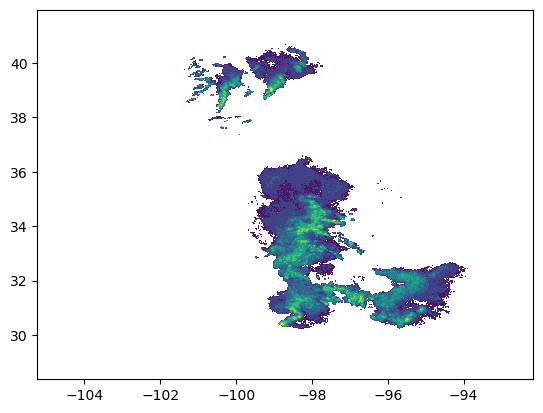

In [58]:
masked = np.ma.masked_inside(gridded_KTLX, -40, 20)  
plt.contourf(gridded_KTLX.longitude,gridded_KTLX.latitude,masked)
masked = np.ma.masked_inside(gridded_KDDC, -40, 20)  
plt.contourf(gridded_KDDC.longitude,gridded_KDDC.latitude,masked)
masked = np.ma.masked_inside(gridded_KFWS, -40, 20)  
plt.contourf(gridded_KFWS.longitude,gridded_KFWS.latitude,masked)

In [68]:
def plot_AWE(lon, lat, data,
    levels=None, cmap="viridis", ax=None,
    *, add_states=True, coastline_res="110m",
    boundary_samples=80, gridline_kwargs=None, contourf_kwargs=None):
    """
    Plot filled contours on a Cartopy GeoAxes with a nice boundary + gridlines.

    Returns
    -------
    contour : QuadContourSet
        The contourf result (useful for colorbars).
    """
    if ax is None:
        raise ValueError("Please pass a Cartopy GeoAxes in `ax`.")

    # Robust min/max for numpy or xarray
    lon_min = float(np.nanmin(lon))+1
    lon_max = float(np.nanmax(lon))-1
    lat_min = float(np.nanmin(lat))+0.5
    lat_max = float(np.nanmax(lat))-0.5

    # Boundary + extent
    xs = np.linspace(lon_min, lon_max, boundary_samples)
    ys = np.linspace(lat_min, lat_max, boundary_samples)
    path = nice_boundary_path_for_maps(xs, ys)
    ax.set_boundary(path, transform=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    # Features
    ax.coastlines(resolution=coastline_res)
    if add_states:
        try:
            ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor="k", facecolor="none")
        except Exception:
            pass  # e.g. non-US or feature unavailable

    # Gridlines
    if gridline_kwargs is None:
        gridline_kwargs = dict(draw_labels=True, linewidth=1, color="gray",
                               alpha=0.5, linestyle="--")
    gl = ax.gridlines(**gridline_kwargs)
    gl.top_labels = False
    gl.right_labels = True  # usually cleaner than True
    gl.bottom_labels = True
    gl.left_labels = False

    # Contours
    if contourf_kwargs is None:
        contourf_kwargs = {}
    contour = ax.contourf(lon, lat, data, levels=levels,
        cmap=cmap, transform=ccrs.PlateCarree(), extend="both", **contourf_kwargs)

    return contour

def nice_boundary_path_for_maps(lon,lat):
    
    Path = mpath.Path
    path_data = [(Path.MOVETO, (lon.min(), lat.min()))]

    for lo in lon:
        path_data.append((Path.LINETO, (lo, lat.min())))
    
    path_data.append((Path.LINETO, (lon.max(), lat.max())))

    for lo in np.flip(lon):
        path_data.append((Path.LINETO, (lo, lat.max())))
    
    path_data.append((Path.CLOSEPOLY, (lon.min(), lat.min())))
    codes, verts = zip(*path_data)
    path = mpath.Path(verts, codes)

    return path

import matplotlib.path as mpath
import cartopy.crs as ccrs

In [76]:
gridded_KFWS.values

array([[-33., -33., -33., ..., -33., -33., -33.],
       [-33., -33., -33., ..., -33., -33., -33.],
       [-33., -33., -33., ..., -33., -33., -33.],
       ...,
       [-33., -33., -33., ..., -33., -33., -33.],
       [-33., -33., -33., ..., -33., -33., -33.],
       [-33., -33., -33., ..., -33., -33., -33.]], shape=(841, 991))

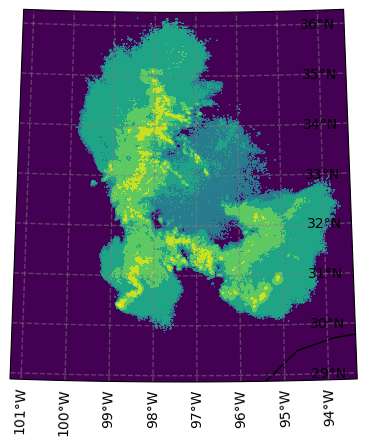

In [78]:
projStr = ccrs.Stereographic(central_longitude=ds_KFWS.longitude.values, central_latitude=ds_KFWS.latitude.values)
fig=plt.figure()
ax=fig.add_subplot(projection=projStr)
plot_AWE(gridded_KFWS.longitude,gridded_KFWS.latitude,gridded_KFWS.values,ax=ax)